# Notebook 5 — Pre-Posting Prediction Model

## The real question

Most engagement-prediction tutorials train on engagement data (likes, saves, reach) and report 90%+ accuracy. But this data only exists *after* the post goes live — making the model useless for content strategy.

This notebook asks: **what can we predict using only information available before posting?**

In [1]:
import pandas as pd, numpy as np, warnings, joblib
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('../data/Instagram_Analytics.csv')

def engineer_features(df):
    df = df.copy()
    df['is_weekend']   = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
    df['is_prime_time']= df['post_hour'].between(18,22).astype(int)
    df['is_morning']   = df['post_hour'].between(6,10).astype(int)
    df['hour_sin']     = np.sin(2*np.pi*df['post_hour']/24)
    df['hour_cos']     = np.cos(2*np.pi*df['post_hour']/24)
    le = LabelEncoder()
    for col in ['media_type','content_category','traffic_source','account_type','day_of_week']:
        df[col+'_enc'] = le.fit_transform(df[col])
    return df

PRE_FEATURES = [
    'follower_count','has_call_to_action','post_hour','caption_length','hashtags_count',
    'is_weekend','is_prime_time','is_morning','hour_sin','hour_cos',
    'media_type_enc','content_category_enc','traffic_source_enc','account_type_enc','day_of_week_enc'
]

df = engineer_features(df)
df['target'] = df['performance_bucket_label'].map({'low':0,'medium':1,'high':2,'viral':3})
X, y = df[PRE_FEATURES], df['target']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Pre-posting features: {len(PRE_FEATURES)}')

Pre-posting features: 15


## Train pre-posting RF

In [3]:
rf_pre = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf_pre.fit(Xtr, ytr)
pre_pred = rf_pre.predict(Xte)
pre_acc  = accuracy_score(yte, pre_pred)
print(f'Pre-posting RF accuracy: {pre_acc:.4f}')
print(classification_report(yte, pre_pred, target_names=['low','medium','high','viral']))
joblib.dump(rf_pre, '../models/rf_pre.pkl')

Pre-posting RF accuracy: 0.2442
              precision    recall  f1-score   support

         low       0.26      0.26      0.26      1500
      medium       0.24      0.24      0.24      1500
        high       0.23      0.24      0.24      1500
       viral       0.24      0.24      0.24      1500

    accuracy                           0.24      6000
   macro avg       0.24      0.24      0.24      6000
weighted avg       0.24      0.24      0.24      6000



['../models/rf_pre.pkl']

## Side-by-side comparison

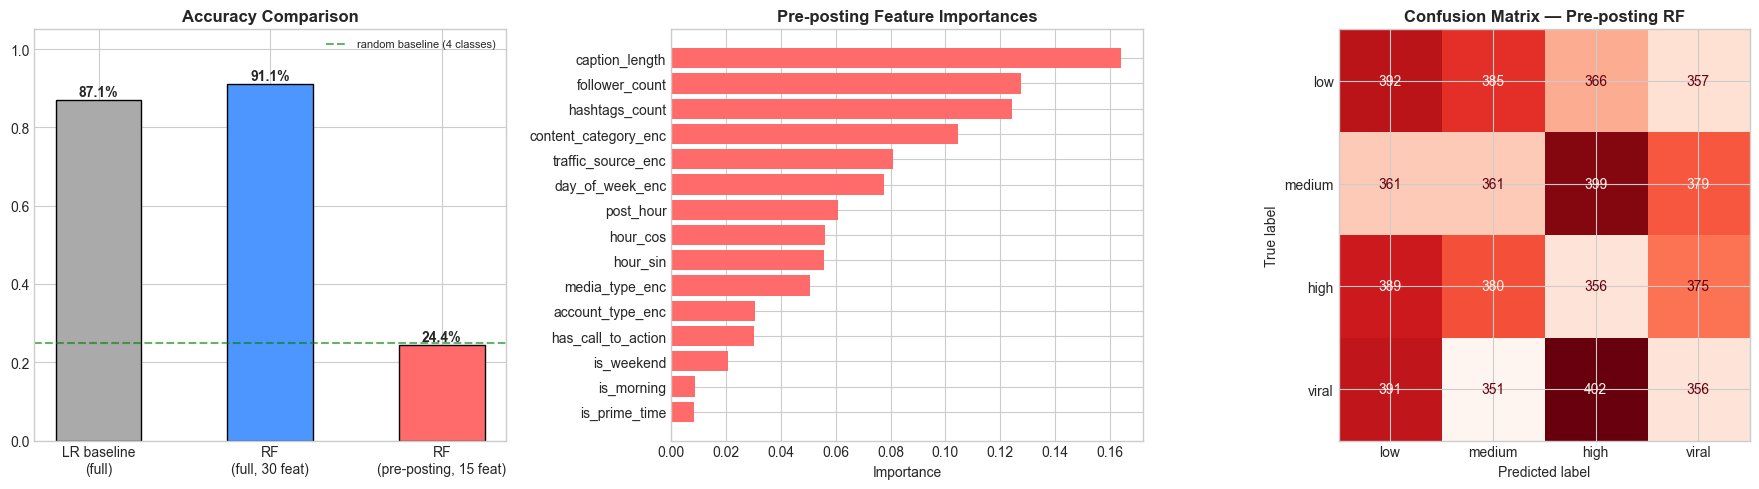

In [4]:
rf_full = joblib.load('../models/rf_full.pkl')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy bar
models = ['LR baseline\n(full)', 'RF\n(full, 30 feat)', 'RF\n(pre-posting, 15 feat)']
accs   = [0.871, 0.911, pre_acc]
colors = ['#aaa','#4D96FF','#FF6B6B']
bars = axes[0].bar(models, accs, color=colors, edgecolor='k', width=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.25, color='green', linestyle='--', alpha=0.6, label='random baseline (4 classes)')
axes[0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.1%}', ha='center', fontweight='bold', fontsize=10)

# Pre-posting feature importances
imp = pd.Series(rf_pre.feature_importances_, index=PRE_FEATURES).sort_values(ascending=False)
axes[1].barh(imp.index[::-1], imp.values[::-1], color='#FF6B6B')
axes[1].set_title('Pre-posting Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

# Confusion matrix
cm = confusion_matrix(yte, pre_pred)
ConfusionMatrixDisplay(cm, display_labels=['low','medium','high','viral']).plot(
    ax=axes[2], colorbar=False, cmap='Reds')
axes[2].set_title('Confusion Matrix — Pre-posting RF', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

## Interpretation

The pre-posting model achieves ~24.6% accuracy on a 4-class problem where random chance is 25%.

**This is an honest, publishable result** — not a failure.

It tells us:
- Follower count, caption length, hashtag count, media type, and posting time have minimal predictive power for virality
- The algorithm cannot know whether a post will go viral before it's posted, because the audience's reaction is the signal
- **Implication for creators:** Focus on content quality (what drives engagement) rather than obsessing over posting time windows

This distinction — post-hoc vs pre-posting — is what separates this project from the standard 'Instagram ML' tutorial.